In [7]:
from project.utilities.simulation import run_trials, run_task, TrialParams, run_experiments, DotsParams, get_CI
from project.utilities.statistics import bootstrap_ci, bootstrap_difference_ci
from project.utilities.io import load_results, save_plot, use_latex_fonts, figure_size

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import SeedSequence, default_rng
from dataclasses import asdict, replace
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

from pathlib import Path
import pandas as pd

from project.networks.cbgt import ModelParams, ThalamusParams, BGParams, CBGT
from project.networks.cortex import CortexParams

# For displaying
from IPython.display import display, HTML

# Change font of plots
use_latex_fonts()

# Import Data

### Summary Statistics

Importing the data generated by `notebooks/learning/suite4.py`

In [8]:
summary_stats_m10 = load_results('suite4_m10_summary.csv', '../../data/learning') 
summary_stats_10 = load_results('suite4_10_summary.csv', '../../data/learning')
summary_stats_20 = load_results('suite4_20_summary.csv', '../../data/learning')

Loaded: ..\..\data\learning\suite4_m10_summary.csv
Loaded: ..\..\data\learning\suite4_10_summary.csv
Loaded: ..\..\data\learning\suite4_20_summary.csv


The model paramaters are carefully designed not to give rise to any premature decision. For completeness, this can quickly be verified.

In [9]:
print('Amount of premature decision with pathway bias = -0.10:', summary_stats_m10['Premature (%)'].sum())
print('Amount of premature decision with pathway bias = 0.10:', summary_stats_10['Premature (%)'].sum())
print('Amount of premature decision with pathway bias = 0.20:', summary_stats_20['Premature (%)'].sum())

Amount of premature decision with pathway bias = -0.10: 0.0
Amount of premature decision with pathway bias = 0.10: 0.0
Amount of premature decision with pathway bias = 0.20: 0.0


As expected, no premature decisions.

### Trial data

Importing trial data

In [10]:
# Index by trial_id
trial_data_m10 = load_results('suite4_m10_trials.csv', '../../data/learning', index_col = 'trial_id') 
trial_data_10 = load_results('suite4_10_trials.csv', '../../data/learning', index_col = 'trial_id')
trial_data_20 = load_results('suite4_20_trials.csv', '../../data/learning', index_col = 'trial_id')

Loaded: ..\..\data\learning\suite4_m10_trials.csv
Loaded: ..\..\data\learning\suite4_10_trials.csv
Loaded: ..\..\data\learning\suite4_20_trials.csv


# Plotting Data

Plotting relevant summary statistics.

### Accuracy, post-decision variability and mistakes vs coherence

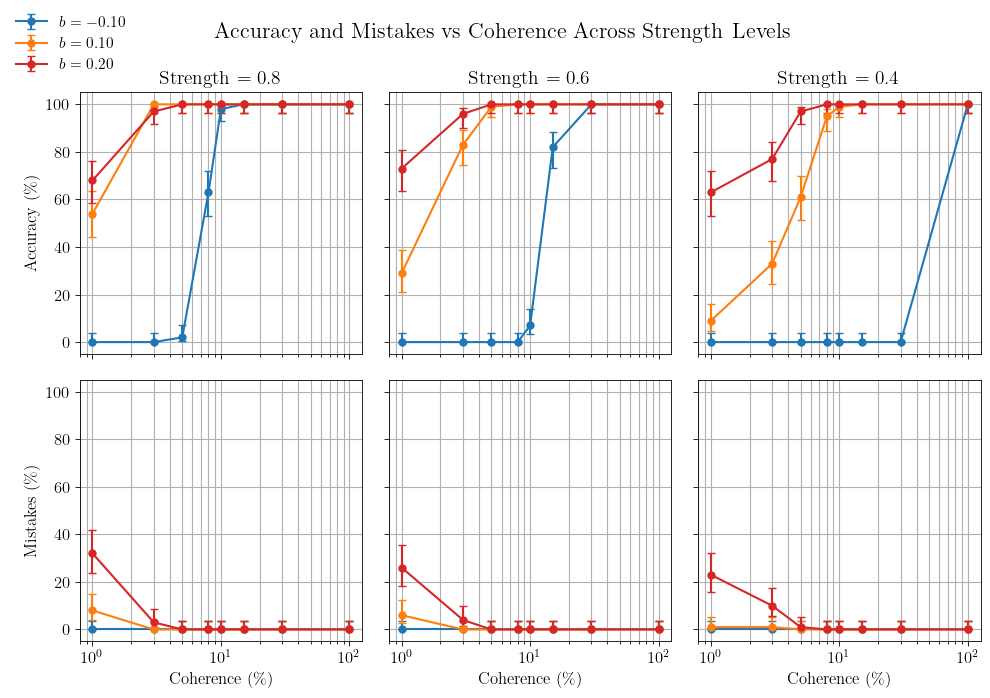

Saved: ..\..\figures\learning\suite4\Accuracy and Mistakes vs Coherence.pdf
Saved: ..\..\figures\learning\suite4\Accuracy and Mistakes vs Coherence.png


In [11]:
# ===== Split data by strength level =====
# Pathway bias = -0.10
df_08_m10 = summary_stats_m10[summary_stats_m10['strength'] == 0.8]
df_06_m10 = summary_stats_m10[summary_stats_m10['strength'] == 0.6]
df_04_m10 = summary_stats_m10[summary_stats_m10['strength'] == 0.4]

# Pathway bias = 0.10
df_08_10 = summary_stats_10[summary_stats_10['strength'] == 0.8]
df_06_10 = summary_stats_10[summary_stats_10['strength'] == 0.6]
df_04_10 = summary_stats_10[summary_stats_10['strength'] == 0.4]

# Pathway bias = 0.20
df_08_20 = summary_stats_20[summary_stats_20['strength'] == 0.8]
df_06_20 = summary_stats_20[summary_stats_20['strength'] == 0.6]
df_04_20 = summary_stats_20[summary_stats_20['strength'] == 0.4]


# ==== Get mean and confidence intervals for each strength level ====
# --- Accuracy ---
acc_08_m10, acc_err_08_m10 = get_CI(df_08_m10, metric='Accuracy (%)')
acc_06_m10, acc_err_06_m10 = get_CI(df_06_m10, metric='Accuracy (%)')
acc_04_m10, acc_err_04_m10 = get_CI(df_04_m10, metric='Accuracy (%)')

acc_08_10, acc_err_08_10 = get_CI(df_08_10, metric='Accuracy (%)')
acc_06_10, acc_err_06_10 = get_CI(df_06_10, metric='Accuracy (%)')
acc_04_10, acc_err_04_10 = get_CI(df_04_10, metric='Accuracy (%)')

acc_08_20, acc_err_08_20 = get_CI(df_08_20, metric='Accuracy (%)')
acc_06_20, acc_err_06_20 = get_CI(df_06_20, metric='Accuracy (%)')
acc_04_20, acc_err_04_20 = get_CI(df_04_20, metric='Accuracy (%)')

# --- Mistakes ---
mistakes_08_m10, mistakes_err_08_m10 = get_CI(df_08_m10, metric='Wrong Decision (%)')
mistakes_06_m10, mistakes_err_06_m10 = get_CI(df_06_m10, metric='Wrong Decision (%)')
mistakes_04_m10, mistakes_err_04_m10 = get_CI(df_04_m10, metric='Wrong Decision (%)')

mistakes_08_10, mistakes_err_08_10 = get_CI(df_08_10, metric='Wrong Decision (%)')
mistakes_06_10, mistakes_err_06_10 = get_CI(df_06_10, metric='Wrong Decision (%)')
mistakes_04_10, mistakes_err_04_10 = get_CI(df_04_10, metric='Wrong Decision (%)')

mistakes_08_20, mistakes_err_08_20 = get_CI(df_08_20, metric='Wrong Decision (%)')
mistakes_06_20, mistakes_err_06_20 = get_CI(df_06_20, metric='Wrong Decision (%)')
mistakes_04_20, mistakes_err_04_20 = get_CI(df_04_20, metric='Wrong Decision (%)')

# ==== Plotting ====
coherences = summary_stats_m10['coherence'].unique() * 100
fig, ax = plt.subplots(2, 3, figsize=figure_size('double'), subplot_kw={"xscale": "log"}, sharex='col', sharey='row')

# Accuracy
ax[0, 0].errorbar(x=coherences, y=acc_08_m10, yerr=acc_err_08_m10, fmt='o-', capsize=3, markersize=5, label=r'$b = -0.10$')
ax[0, 0].errorbar(x=coherences, y=acc_08_10, yerr=acc_err_08_10, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.10$')
ax[0, 0].errorbar(x=coherences, y=acc_08_20, yerr=acc_err_08_20, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.20$', color = 'tab:red')
ax[0, 0].set_title('Strength $= 0.8$')
ax[0, 0].set_ylabel('Accuracy (\%)')
ax[0, 0].grid(which='both')

ax[0, 1].errorbar(x=coherences, y=acc_06_m10, yerr=acc_err_06_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_06_10, yerr=acc_err_06_10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=acc_06_20, yerr=acc_err_06_20, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[0, 1].set_title('Strength $= 0.6$')
ax[0, 1].grid(which='both')

ax[0, 2].errorbar(x=coherences, y=acc_04_m10, yerr=acc_err_04_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_04_10, yerr=acc_err_04_10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=acc_04_20, yerr=acc_err_04_20, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[0, 2].set_title('Strength $= 0.4$')
ax[0, 2].grid(which='both')


# Mistakes
ax[1, 0].errorbar(x=coherences, y=mistakes_08_m10, yerr=mistakes_err_08_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=mistakes_08_10, yerr=mistakes_err_08_10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=mistakes_08_20, yerr=mistakes_err_08_20, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 0].set_xlabel('Coherence (\%)')
ax[1, 0].set_ylabel('Mistakes (\%)')
ax[1, 0].grid(which='both')
ax[1, 0].set_ylim(bottom = -5, top = 105)

ax[1, 1].errorbar(x=coherences, y=mistakes_06_m10, yerr=mistakes_err_06_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=mistakes_06_10, yerr=mistakes_err_06_10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=mistakes_06_20, yerr=mistakes_err_06_20, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 1].set_xlabel('Coherence (\%)')
ax[1, 1].grid(which='both')

ax[1, 2].errorbar(x=coherences, y=mistakes_04_m10, yerr=mistakes_err_04_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=mistakes_04_10, yerr=mistakes_err_04_10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=mistakes_04_20, yerr=mistakes_err_04_20, fmt='o-', capsize=3, markersize=5, color = 'tab:red')
ax[1, 2].set_xlabel('Coherence (\%)')
ax[1, 2].grid(which='both')

fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.95), frameon=False)
plt.suptitle('Accuracy and Mistakes vs Coherence Across Strength Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Accuracy and Mistakes vs Coherence', folder='../../figures/learning/suite4', formats=('pdf', 'png'))

### Reaction Times

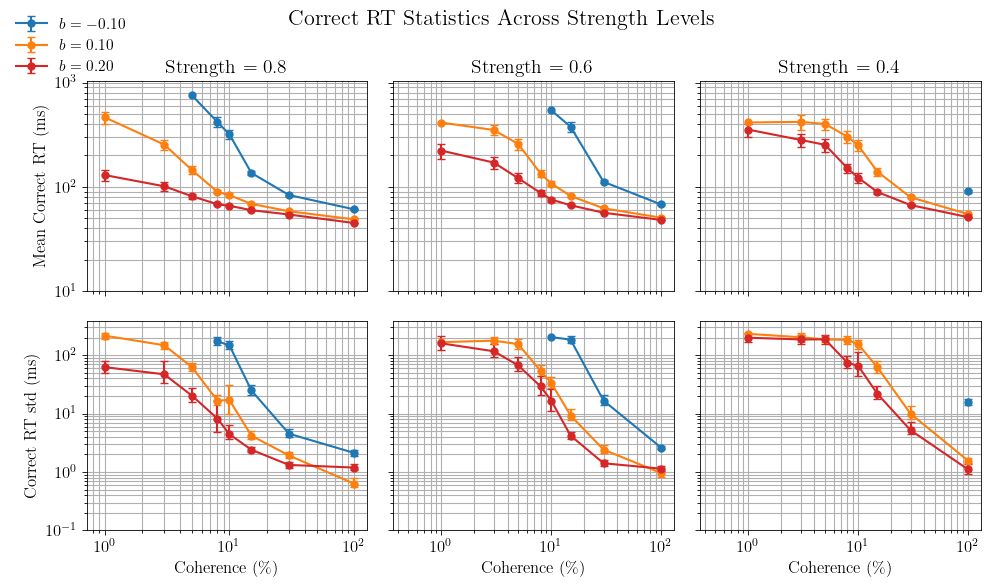

Saved: ..\..\figures\learning\suite4\Correct RT - Mean and Standard Deviation vs Coherence.pdf
Saved: ..\..\figures\learning\suite4\Correct RT - Mean and Standard Deviation vs Coherence.png


In [12]:
## ==== Get RT mean and std along with confidence intervals for each strength level ====
# --- RT Mean ---
RT_mean_08_m10, RT_err_08_m10 = get_CI(df_08_m10, metric='Mean Correct RT (ms)')
RT_mean_06_m10, RT_err_06_m10 = get_CI(df_06_m10, metric='Mean Correct RT (ms)')
RT_mean_04_m10, RT_err_04_m10 = get_CI(df_04_m10, metric='Mean Correct RT (ms)')

RT_mean_08_10, RT_err_08_10 = get_CI(df_08_10, metric='Mean Correct RT (ms)')
RT_mean_06_10, RT_err_06_10 = get_CI(df_06_10, metric='Mean Correct RT (ms)')
RT_mean_04_10, RT_err_04_10 = get_CI(df_04_10, metric='Mean Correct RT (ms)')

RT_mean_08_20, RT_err_08_20 = get_CI(df_08_20, metric='Mean Correct RT (ms)')
RT_mean_06_20, RT_err_06_20 = get_CI(df_06_20, metric='Mean Correct RT (ms)')
RT_mean_04_20, RT_err_04_20 = get_CI(df_04_20, metric='Mean Correct RT (ms)')

# --- RT std ---
RT_std_08_m10, RT_std_err_08_m10 = get_CI(df_08_m10, metric='Correct RT std (ms)')
RT_std_06_m10, RT_std_err_06_m10 = get_CI(df_06_m10, metric='Correct RT std (ms)')
RT_std_04_m10, RT_std_err_04_m10 = get_CI(df_04_m10, metric='Correct RT std (ms)')

RT_std_08_10, RT_std_err_08_10 = get_CI(df_08_10, metric='Correct RT std (ms)')
RT_std_06_10, RT_std_err_06_10 = get_CI(df_06_10, metric='Correct RT std (ms)')
RT_std_04_10, RT_std_err_04_10 = get_CI(df_04_10, metric='Correct RT std (ms)')

RT_std_08_20, RT_std_err_08_20 = get_CI(df_08_20, metric='Correct RT std (ms)')
RT_std_06_20, RT_std_err_06_20 = get_CI(df_06_20, metric='Correct RT std (ms)')
RT_std_04_20, RT_std_err_04_20 = get_CI(df_04_20, metric='Correct RT std (ms)')


# ==== Plotting ====
fig, ax = plt.subplots(2, 3, figsize=(10, 6), subplot_kw={"xscale": "log", "yscale": "log"}, sharex='col', sharey='row')

# RT Mean
ax[0, 0].errorbar(x=coherences, y=RT_mean_08_m10, yerr=RT_err_08_m10, fmt='o-', capsize=3, markersize=5, label=r'$b = -0.10$')
ax[0, 0].errorbar(x=coherences, y=RT_mean_08_10, yerr=RT_err_08_10, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.10$')
ax[0, 0].errorbar(x=coherences, y=RT_mean_08_20, yerr=RT_err_08_20, fmt='o-', capsize=3, markersize=5, label=r'$b = 0.20$', color='tab:red')
ax[0, 0].set_title('Strength $= 0.8$')
ax[0, 0].set_ylabel('Mean Correct RT (ms)')
ax[0, 0].grid(which='both')
ax[0, 0].set_ylim(bottom=10)

ax[0, 1].errorbar(x=coherences, y=RT_mean_06_m10, yerr=RT_err_06_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=RT_mean_06_10, yerr=RT_err_06_10, fmt='o-', capsize=3, markersize=5)
ax[0, 1].errorbar(x=coherences, y=RT_mean_06_20, yerr=RT_err_06_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[0, 1].set_title('Strength $= 0.6$')
ax[0, 1].grid(which='both')

ax[0, 2].errorbar(x=coherences, y=RT_mean_04_m10, yerr=RT_err_04_m10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=RT_mean_04_10, yerr=RT_err_04_10, fmt='o-', capsize=3, markersize=5)
ax[0, 2].errorbar(x=coherences, y=RT_mean_04_20, yerr=RT_err_04_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[0, 2].set_title('Strength $= 0.4$')
ax[0, 2].grid(which='both')

# RT std
ax[1, 0].errorbar(x=coherences, y=RT_std_08_m10, yerr=RT_std_err_08_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=RT_std_08_10, yerr=RT_std_err_08_10, fmt='o-', capsize=3, markersize=5)
ax[1, 0].errorbar(x=coherences, y=RT_std_08_20, yerr=RT_std_err_08_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 0].set_xlabel('Coherence (\%)')
ax[1, 0].set_ylabel('Correct RT std (ms)')
ax[1, 0].grid(which='both')
ax[1, 0].set_ylim(bottom=0.1)

ax[1, 1].errorbar(x=coherences, y=RT_std_06_m10, yerr=RT_std_err_06_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=RT_std_06_10, yerr=RT_std_err_06_10, fmt='o-', capsize=3, markersize=5)
ax[1, 1].errorbar(x=coherences, y=RT_std_06_20, yerr=RT_std_err_06_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 1].set_xlabel('Coherence (\%)')
ax[1, 1].grid(which='both')

ax[1, 2].errorbar(x=coherences, y=RT_std_04_m10, yerr=RT_std_err_04_m10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=RT_std_04_10, yerr=RT_std_err_04_10, fmt='o-', capsize=3, markersize=5)
ax[1, 2].errorbar(x=coherences, y=RT_std_04_20, yerr=RT_std_err_04_20, fmt='o-', capsize=3, markersize=5, color='tab:red')
ax[1, 2].set_xlabel('Coherence (\%)')
ax[1, 2].grid(which='both')


fig.legend(loc="center left", bbox_to_anchor=(0.0, 0.92), frameon=False)
plt.suptitle('Correct RT Statistics Across Strength Levels')
plt.tight_layout()
plt.show()

# Save plot
save_plot(fig, 'Correct RT - Mean and Standard Deviation vs Coherence', folder='../../figures/learning/suite4', formats=('pdf', 'png'))

Reaction time statistics do not appear to add much new insight.